# **EDA for House Price Prediction (MLR)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

from pathlib import Path

In [2]:
# Defining Dataset path

DATASET_PATH = "C:\\Users\\boddu\OneDrive\Documents\Machine Learning\Multiple Linear Regression\House Price Prediction\data\house_price.csv"

In [3]:
df = pd.read_csv(DATASET_PATH)

In [4]:
# first we have kept real dataset in df_raw
df_raw = df.copy()

In [5]:
# checking dataset shape
df.shape

(5000, 10)

In [6]:
# Initial Dataset Aduilt

# Dataset Head
df.head()


,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Location,Distance_to_City_km,HasGarage,School_Rating,Price
0,1473.9,2,2.0,1,1,Suburban,7.6,Yes,8.3,276000
1,1188.7,2,2.0,10,3,Rural,33.3,Yes,7.1,190100
2,2295.2,4,3.0,10,2,Rural,21.8,Yes,7.4,344300
3,1425.0,3,2.0,29,1,Suburban,11.9,Yes,4.9,264300
4,2037.9,2,1.0,3,1,Suburban,13.5,Yes,5.6,335100


In [7]:
# Dataset Tail
df.tail()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Floors,Location,Distance_to_City_km,HasGarage,School_Rating,Price
4995,1897.1,3,2.0,29,1,Suburban,10.2,Yes,7.500000,305100
4996,2042.6,4,2.0,1,2,Downtown,0.2,Yes,6.581563,412400
4997,1675.0,3,2.0,11,1,Suburban,12.0,No,9.200000,303000
4998,1381.7,2,1.0,32,1,Downtown,3.3,Yes,8.691494,289400
4999,1820.4,4,3.0,7,3,Suburban,2.8,Yes,7.400000,426200


In [8]:
# Datset Shape
df.shape

(5000, 10)

In [9]:
#Dataset Columns
df.columns.tolist()

['Area_sqft',
 'Bedrooms',
 'Bathrooms',
 'Age_years',
 'Floors',
 'Location',
 'Distance_to_City_km',
 'HasGarage',
 'School_Rating',
 'Price']

In [10]:
#Dataset Types
df.dtypes

Area_sqft              float64
Bedrooms                 int64
Bathrooms              float64
Age_years                int64
Floors                   int64
Location                   str
Distance_to_City_km    float64
HasGarage                  str
School_Rating          float64
Price                    int64
dtype: object

In [11]:
#into
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            5000 non-null   float64
 1   Bedrooms             5000 non-null   int64  
 2   Bathrooms            4960 non-null   float64
 3   Age_years            5000 non-null   int64  
 4   Floors               5000 non-null   int64  
 5   Location             5000 non-null   str    
 6   Distance_to_City_km  4950 non-null   float64
 7   HasGarage            5000 non-null   str    
 8   School_Rating        4900 non-null   float64
 9   Price                5000 non-null   int64  
dtypes: float64(4), int64(4), str(2)
memory usage: 390.8 KB


In [12]:
target = "Price"

continuous_features = [
    "Area_sqft",
    "Age_years",
    "Distance_to_City_km",
    "School_Rating"
]

discrete_features = [
    "Bedrooms",
    "Bathrooms",
    "Floors"
]

categorical_features = [
    "Location",
    "HasGarage"
]

## **Checking Missing Values**

In [14]:
missing_count = df.isnull().sum()

missing_percentage =  df.isna().mean() * 100

missing_result = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_result

,Missing Count,Missing Percentage
Area_sqft,0,0.0
Bedrooms,0,0.0
Bathrooms,40,0.8
Age_years,0,0.0
Floors,0,0.0
Location,0,0.0
Distance_to_City_km,50,1.0
HasGarage,0,0.0
School_Rating,100,2.0
Price,0,0.0


In [18]:
missing_result = missing_result[
    missing_result["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

missing_result

,Missing Count,Missing Percentage
School_Rating,100,2.0
Distance_to_City_km,50,1.0
Bathrooms,40,0.8


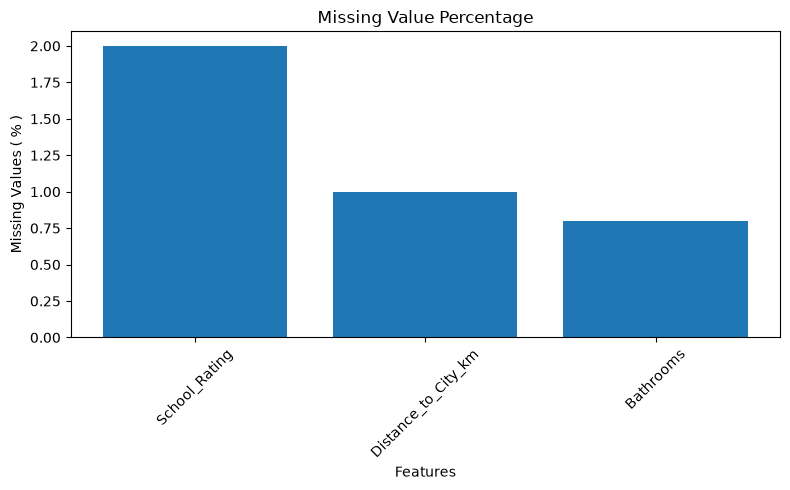

In [27]:
# Visualize the Missing Values

missing_percentage = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage [
    missing_percentage > 0
]


plt.figure(figsize=(8,5))
plt.bar(
    missing_percentage.index,
    missing_percentage.values
)

plt.xlabel("Features")
plt.ylabel("Missing Values ( % )")
plt.title("Missing Value Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# check Duplicated rows
duplicated_values = df.duplicated().sum()

0


In [31]:
duplicate_rows = df[df.duplicated(keep=False)]

In [32]:
cardinality = pd.DataFrame({
    "Unique Values" : df.nunique(),
    "Unique Percentage" : df.nunique()/len(df)*100
})

cardinality

,Unique Values,Unique Percentage
Area_sqft,4325,86.50
Bedrooms,7,0.14
Bathrooms,5,0.10
Age_years,61,1.22
Floors,3,0.06
Location,3,0.06
Distance_to_City_km,441,8.82
HasGarage,2,0.04
School_Rating,1524,30.48
Price,2566,51.32


In [34]:
# Descriptive Analysis
numeric_analysis = df.describe().T
numeric_analysis

,count,mean,std,min,25%,50%,75%,max
Area_sqft,5000.0,1796.279520,519.364951,694.0,1432.200000,1728.85,2075.0750,5163.4
Bedrooms,5000.0,3.252200,1.131040,1.0,3.000000,3.00,4.0000,7.0
Bathrooms,4960.0,2.149194,0.873254,1.0,2.000000,2.00,3.0000,5.0
Age_years,5000.0,15.261200,14.274723,0.0,5.000000,11.00,21.0000,60.0
Floors,5000.0,1.634000,0.645079,1.0,1.000000,2.00,2.0000,3.0
Distance_to_City_km,4950.0,12.280949,10.005579,0.2,3.900000,11.10,16.4000,53.5
School_Rating,4900.0,6.580528,1.755881,1.0,5.367385,6.60,7.8414,10.0
Price,5000.0,329455.600000,92792.569060,102000.0,267700.000000,318250.00,378825.0000,1252500.0


In [35]:
numeric_analysis["Range"] = numeric_analysis["max"] - numeric_analysis["min"]
numeric_analysis["IQR"] = numeric_analysis["75%"] - numeric_analysis["25%"]

numeric_analysis

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Area_sqft,5000.0,1796.279520,519.364951,694.0,1432.200000,1728.85,2075.0750,5163.4,4469.4,642.875000
Bedrooms,5000.0,3.252200,1.131040,1.0,3.000000,3.00,4.0000,7.0,6.0,1.000000
Bathrooms,4960.0,2.149194,0.873254,1.0,2.000000,2.00,3.0000,5.0,4.0,1.000000
Age_years,5000.0,15.261200,14.274723,0.0,5.000000,11.00,21.0000,60.0,60.0,16.000000
Floors,5000.0,1.634000,0.645079,1.0,1.000000,2.00,2.0000,3.0,2.0,1.000000
Distance_to_City_km,4950.0,12.280949,10.005579,0.2,3.900000,11.10,16.4000,53.5,53.3,12.500000
School_Rating,4900.0,6.580528,1.755881,1.0,5.367385,6.60,7.8414,10.0,9.0,2.474015
Price,5000.0,329455.600000,92792.569060,102000.0,267700.000000,318250.00,378825.0000,1252500.0,1150500.0,111125.000000


In [38]:
# Categorial Feature Analysis
for column in categorical_features:

    print(f"\n{column}")
    print(df[column].value_counts())
    
    print("\nPercentage:")
    print(
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Location
Location
Suburban    2483
Downtown    1519
Rural        998
Name: count, dtype: int64

Percentage:
Location
Suburban    49.66
Downtown    30.38
Rural       19.96
Name: proportion, dtype: float64

HasGarage
HasGarage
Yes    3517
No     1483
Name: count, dtype: int64

Percentage:
HasGarage
Yes    70.34
No     29.66
Name: proportion, dtype: float64


In [39]:
# Target Feature Analysis
print(df["Price"].describe())

count    5.000000e+03
mean     3.294556e+05
std      9.279257e+04
min      1.020000e+05
25%      2.677000e+05
50%      3.182500e+05
75%      3.788250e+05
max      1.252500e+06
Name: Price, dtype: float64


In [40]:
print("Mean:", df["Price"].mean())
print("Median:", df["Price"].median())
print("Std:", df["Price"].std())
print("Skewness:", df["Price"].skew())
print("Kurtosis:", df["Price"].kurt())

Mean: 329455.6
Median: 318250.0
Std: 92792.56906032165
Skewness: 1.3408625216569743
Kurtosis: 6.710904073442635


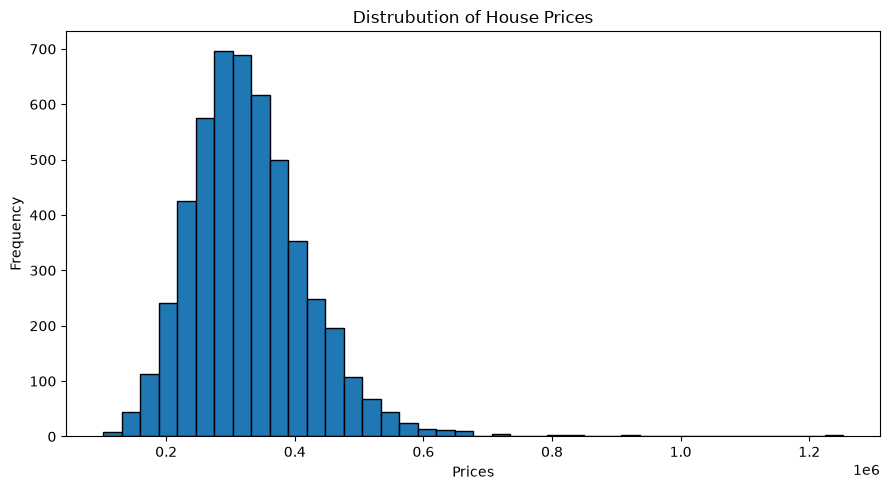

In [41]:
# Target Distribution

plt.figure(figsize=(9,5))

plt.hist(
    df["Price"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Prices")
plt.ylabel("Frequency")
plt.title("Distrubution of House Prices")

plt.tight_layout()
plt.show()

C:\Users\boddu\AppData\Local\Temp\ipykernel_17440\3335689211.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


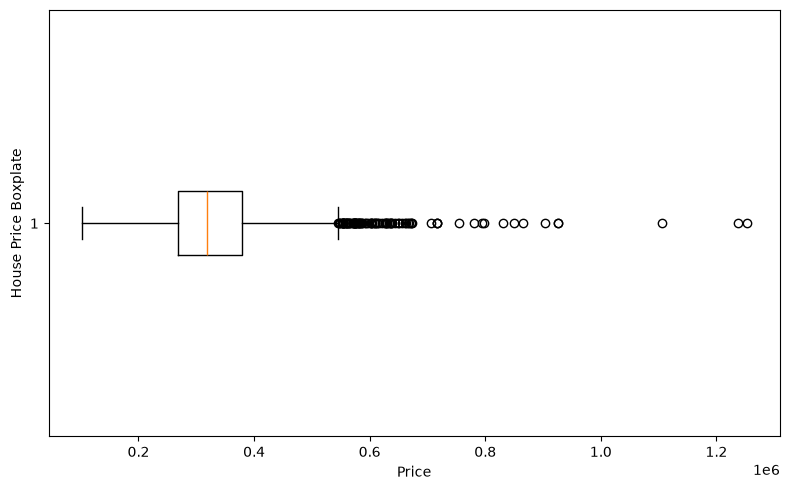

In [42]:
# Box Plot 

plt.figure(figsize=(8,5))

plt.boxplot(
    df["Price"],
    vert=False
)

plt.xlabel("Price")
plt.ylabel("House Price Boxplate")

plt.tight_layout()
plt.show()

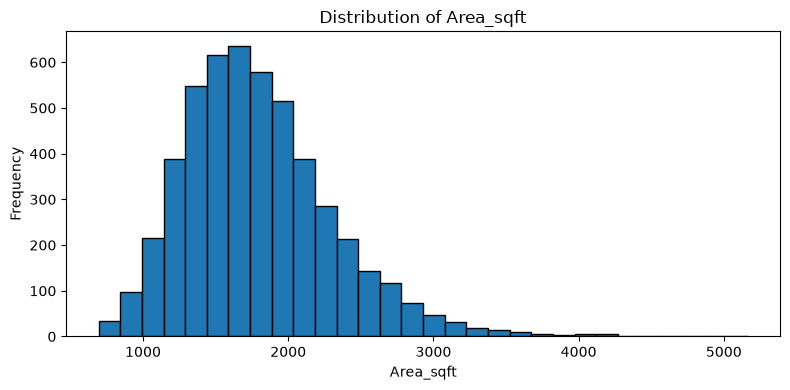

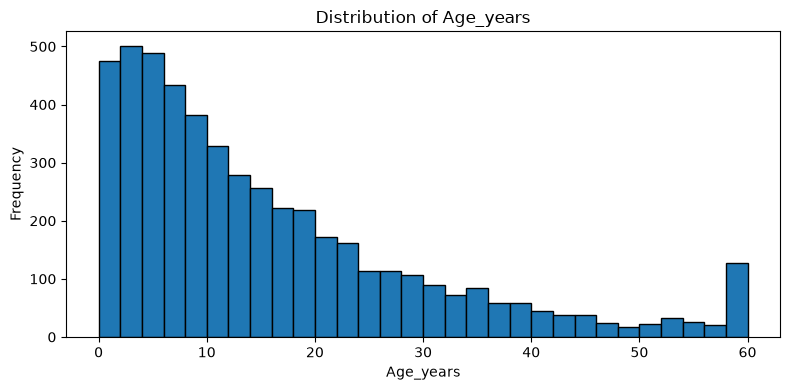

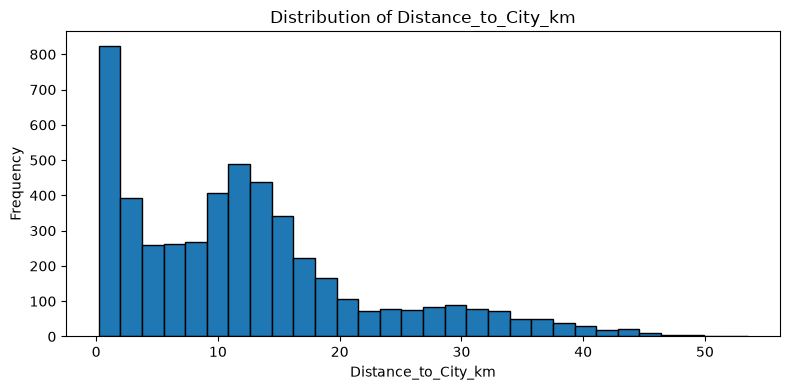

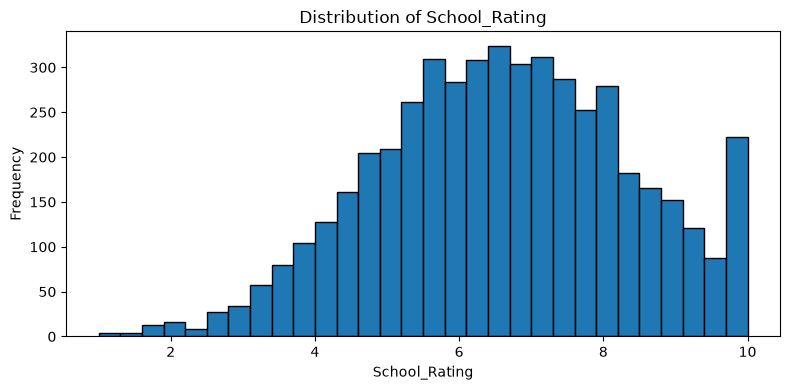

In [45]:
for column in continuous_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

In [46]:
numeric_columns = df.select_dtypes(include=np.number).columns

skewness_report = (
    df[numeric_columns].skew().sort_values(
        key=abs,
        ascending=False
    )
)

print(skewness_report)

Age_years              1.385909
Price                  1.340863
Distance_to_City_km    1.032371
Area_sqft              1.011766
Floors                 0.521274
Bathrooms              0.453492
Bedrooms               0.403641
School_Rating         -0.111276
dtype: float64


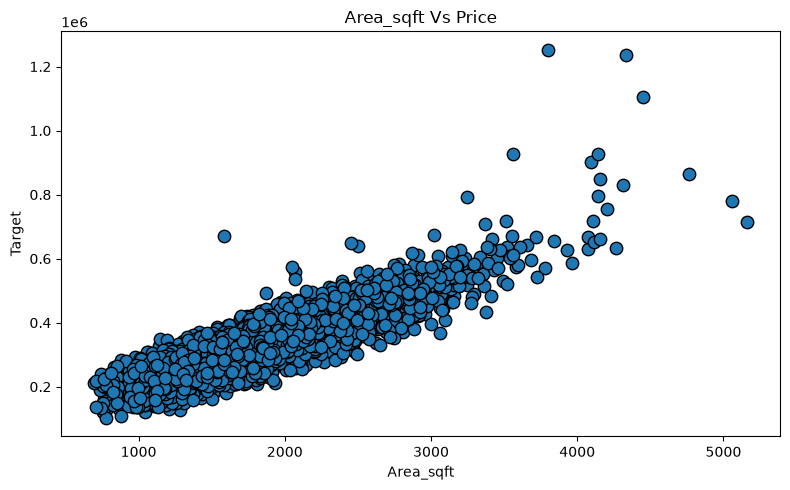

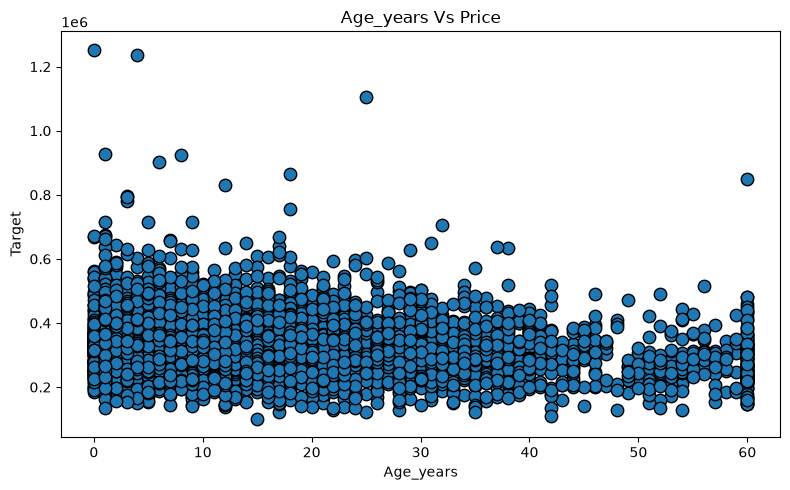

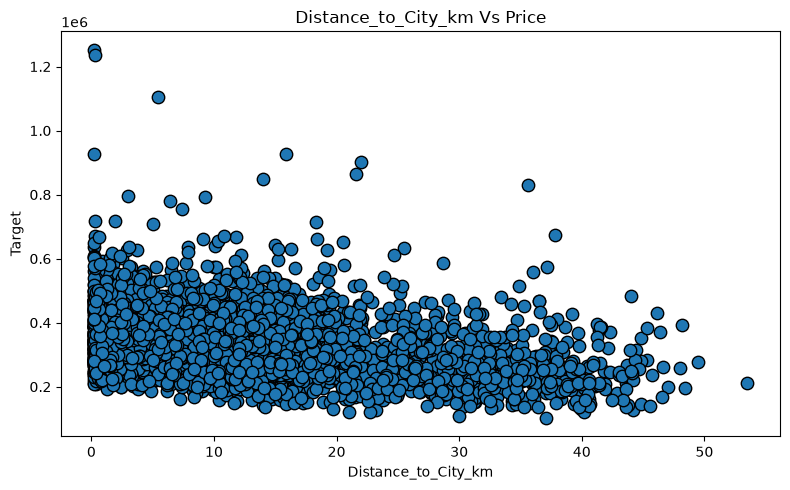

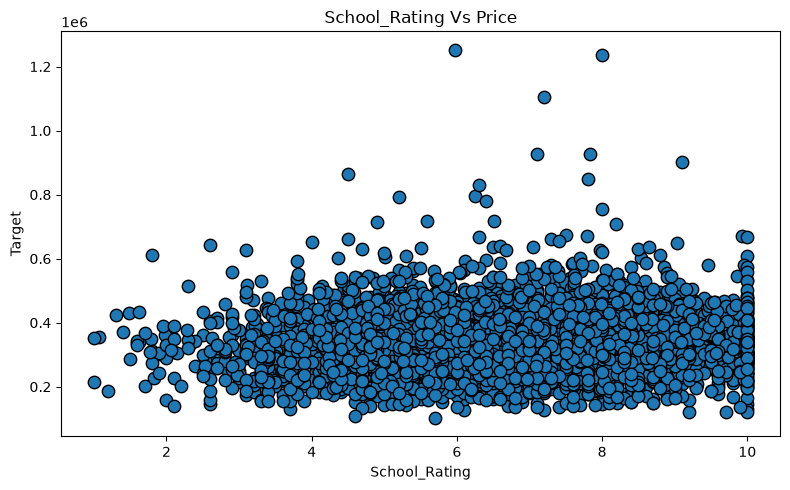

In [48]:
# Feature and Target using scatter plot
for feature in continuous_features:
    plt.figure(figsize=(8,5))

    plt.scatter(
        df[feature],
        df["Price"],
        edgecolors="Black",
        s=80
    )

    plt.xlabel(feature)
    plt.ylabel("Target")

    plt.title(f"{feature} Vs Price")

    plt.tight_layout()
    plt.show()

In [49]:
location_price = (
    df.groupby("Location")["Price"]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
    .sort_values(
        "mean",
        ascending=False
    )
)

print(location_price)

          count           mean    median           std
Location                                              
Downtown   1519  370061.553654  358500.0  89779.140860
Suburban   2483  327218.002416  314800.0  83543.016238
Rural       998  273218.637275  258000.0  88517.899823


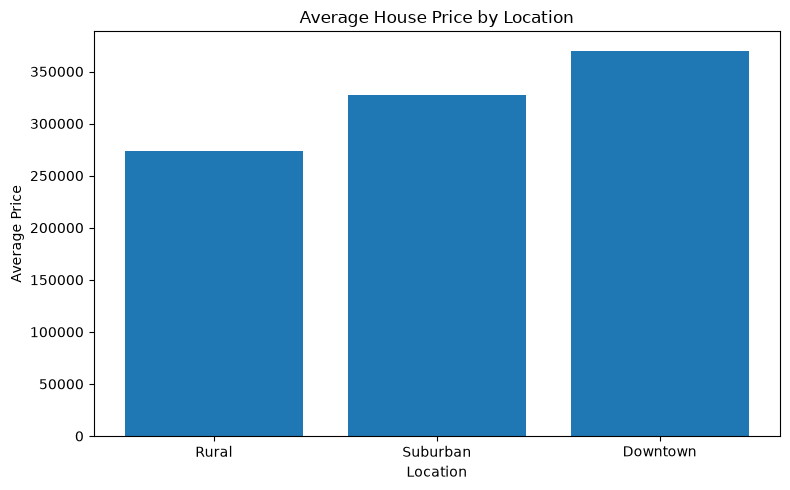

In [50]:
location_mean_price = (
    df.groupby("Location")["Price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.bar(
    location_mean_price.index,
    location_mean_price.values
)

plt.xlabel("Location")
plt.ylabel("Average Price")
plt.title("Average House Price by Location")

plt.tight_layout()
plt.show()

In [51]:
garage_summary = (
    df.groupby("HasGarage")["Price"]
    .agg([
        "count",
        "mean",
        "median"
    ])
)

print(garage_summary)

           count           mean    median
HasGarage                                
No          1483  321977.343223  311700.0
Yes         3517  332608.928064  321500.0


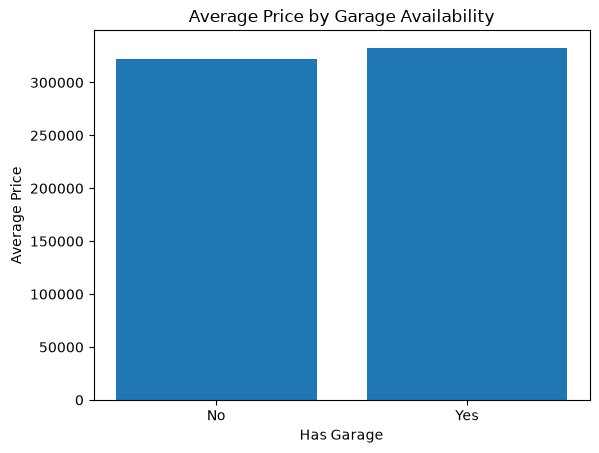

In [52]:
garage_price = (
    df.groupby("HasGarage")["Price"]
    .mean()
)

plt.bar(
    garage_price.index,
    garage_price.values
)

plt.xlabel("Has Garage")
plt.ylabel("Average Price")
plt.title("Average Price by Garage Availability")

plt.show()

In [53]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

print(corr.round(3))

                     Area_sqft  Bedrooms  Bathrooms  Age_years  Floors  \
Area_sqft                1.000     0.795      0.626     -0.017   0.016   
Bedrooms                 0.795     1.000      0.775     -0.006   0.019   
Bathrooms                0.626     0.775      1.000     -0.016   0.020   
Age_years               -0.017    -0.006     -0.016      1.000  -0.021   
Floors                   0.016     0.019      0.020     -0.021   1.000   
Distance_to_City_km     -0.024    -0.005     -0.018     -0.015   0.012   
School_Rating            0.021     0.018      0.003      0.003   0.013   
Price                    0.870     0.731      0.623     -0.146   0.042   

                     Distance_to_City_km  School_Rating  Price  
Area_sqft                         -0.024          0.021  0.870  
Bedrooms                          -0.005          0.018  0.731  
Bathrooms                         -0.018          0.003  0.623  
Age_years                         -0.015          0.003 -0.146  
Floors  

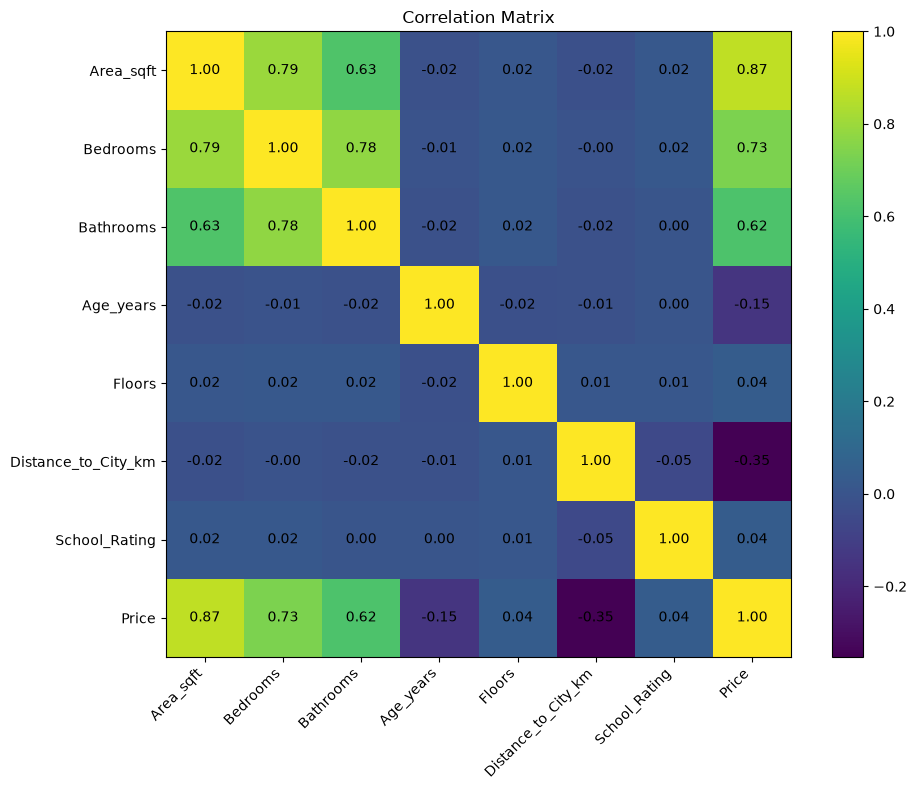

In [54]:
corr = numeric_df.corr()

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(corr)

ax.set_xticks(
    range(len(corr.columns))
)

ax.set_yticks(
    range(len(corr.columns))
)

ax.set_xticklabels(
    corr.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):

        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [55]:
predictor_numeric = [
    column
    for column in numeric_df.columns
    if column != "Price"
]

predictor_corr = (
    df[predictor_numeric]
    .corr()
    .abs()
)

upper_triangle = predictor_corr.where(
    np.triu(
        np.ones(
            predictor_corr.shape
        ),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(
        ascending=False
    )
)

print(
    high_corr_pairs.head(10)
)

Area_sqft            Bedrooms               0.794762
Bedrooms             Bathrooms              0.775281
Area_sqft            Bathrooms              0.625609
Distance_to_City_km  School_Rating          0.052776
Area_sqft            Distance_to_City_km    0.023663
                     School_Rating          0.020971
Age_years            Floors                 0.020616
Bathrooms            Floors                 0.020328
Bedrooms             Floors                 0.018514
                     School_Rating          0.017894
dtype: float64


In [59]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

vif_data = (
    df[predictor_numeric]
    .dropna()
)

vif_report = pd.DataFrame()

vif_report["Feature"] = (
    vif_data.columns
)

vif_report["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(
        vif_data.shape[1]
    )
]

vif_report = vif_report.sort_values(
    "VIF",
    ascending=False
)

print(vif_report)

               Feature        VIF
1             Bedrooms  38.598122
0            Area_sqft  31.623781
2            Bathrooms  17.695622
6        School_Rating   9.316619
4               Floors   6.231557
5  Distance_to_City_km   2.363534
3            Age_years   2.072220


In [60]:
def iqr_outlier_report(
    dataframe,
    columns
):

    reports = []

    for column in columns:

        series = dataframe[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (
            (dataframe[column] < lower)
            |
            (dataframe[column] > upper)
        )

        count = mask.sum()

        reports.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": count,
            "Outlier_Percentage":
                count / len(dataframe) * 100
        })

    return pd.DataFrame(reports)

In [61]:
outlier_report = iqr_outlier_report(
    df,
    list(numeric_columns)
)

print(outlier_report)

               Feature             Q1           Q3            IQR  \
0            Area_sqft    1432.200000    2075.0750     642.875000   
1             Bedrooms       3.000000       4.0000       1.000000   
2            Bathrooms       2.000000       3.0000       1.000000   
3            Age_years       5.000000      21.0000      16.000000   
4               Floors       1.000000       2.0000       1.000000   
5  Distance_to_City_km       3.900000      16.4000      12.500000   
6        School_Rating       5.367385       7.8414       2.474015   
7                Price  267700.000000  378825.0000  111125.000000   

     Lower_Bound    Upper_Bound  Outlier_Count  Outlier_Percentage  
0     467.887500    3039.387500            114                2.28  
1       1.500000       5.500000            375                7.50  
2       0.500000       4.500000             27                0.54  
3     -19.000000      45.000000            269                5.38  
4      -0.500000       3.500000  

In [62]:
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)

iqr = q3 - q1

upper = q3 + 1.5 * iqr

expensive_houses = (
    df[df["Price"] > upper]
    .sort_values(
        "Price",
        ascending=False
    )
)

print(
    expensive_houses.head(20)
)

      Area_sqft  Bedrooms  Bathrooms  Age_years  Floors  Location  \
1131     3798.1         4        3.0          0       2  Downtown   
2166     4334.0         6        4.0          4       1  Downtown   
4496     4446.7         5        3.0         25       2  Suburban   
3082     4143.0         4        3.0          1       1  Suburban   
2356     3562.2         5        3.0          8       2  Downtown   
313      4094.5         5        4.0          6       2     Rural   
3336     4766.2         6        4.0         18       1     Rural   
25       4156.0         6        5.0         60       1  Suburban   
1376     4315.7         5        3.0         12       1     Rural   
1199     4140.5         7        5.0          3       3  Downtown   
2087     3247.0         3        2.0          3       1  Suburban   
1823     5058.2         7        4.0          3       3  Suburban   
83       4205.2         7        5.0         18       2  Suburban   
819      4108.4         6        4

In [63]:
checks = {
    "Area <= 0":
        (df["Area_sqft"] <= 0).sum(),

    "Bedrooms < 0":
        (df["Bedrooms"] < 0).sum(),

    "Bathrooms < 0":
        (df["Bathrooms"] < 0).sum(),

    "Age < 0":
        (df["Age_years"] < 0).sum(),

    "Floors <= 0":
        (df["Floors"] <= 0).sum(),

    "Distance < 0":
        (df["Distance_to_City_km"] < 0).sum(),

    "School Rating < 0":
        (df["School_Rating"] < 0).sum(),

    "School Rating > 10":
        (df["School_Rating"] > 10).sum(),

    "Price <= 0":
        (df["Price"] <= 0).sum()
}

print(pd.Series(checks))

Area <= 0             0
Bedrooms < 0          0
Bathrooms < 0         0
Age < 0               0
Floors <= 0           0
Distance < 0          0
School Rating < 0     0
School Rating > 10    0
Price <= 0            0
dtype: int64


In [64]:
for column in categorical_features:

    print(
        column,
        df[column]
        .value_counts(
            dropna=False
        )
    )

Location Location
Suburban    2483
Downtown    1519
Rural        998
Name: count, dtype: int64
HasGarage HasGarage
Yes    3517
No     1483
Name: count, dtype: int64


In [65]:
eda_df = df.copy()

eda_df["Price_per_sqft"] = (
    eda_df["Price"]
    /
    eda_df["Area_sqft"]
)

In [66]:
print(
    eda_df["Price_per_sqft"]
    .describe()
)

count    5000.000000
mean      185.968507
std        28.597034
min       100.320338
25%       166.871707
50%       184.131747
75%       202.557197
max       423.737374
Name: Price_per_sqft, dtype: float64


In [67]:
location_summary = (
    df.groupby("Location")
    .agg(
        Count=("Price", "size"),
        Mean_Price=("Price", "mean"),
        Median_Price=("Price", "median"),
        Mean_Area=("Area_sqft", "mean"),
        Mean_Distance=(
            "Distance_to_City_km",
            "mean"
        )
    )
)

print(location_summary)

          Count     Mean_Price  Median_Price    Mean_Area  Mean_Distance
Location                                                                
Downtown   1519  370061.553654      358500.0  1807.302633       2.481740
Rural       998  273218.637275      258000.0  1768.157615      27.766498
Suburban   2483  327218.002416      314800.0  1800.839146      12.060220


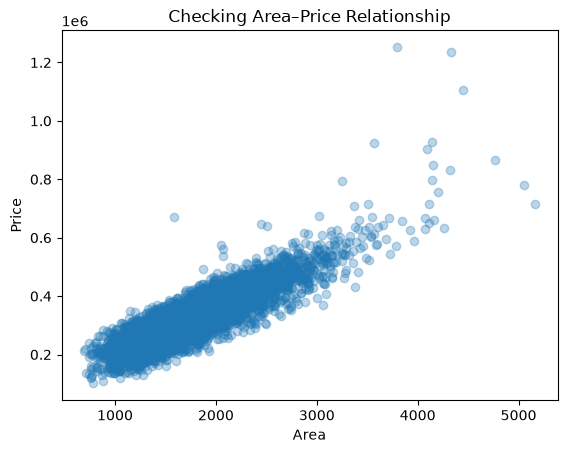

In [68]:
plt.scatter(
    df["Area_sqft"],
    df["Price"],
    alpha=0.3
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Checking Area–Price Relationship")

plt.show()

In [69]:
bedroom_price = (
    df.groupby("Bedrooms")["Price"]
    .agg([
        "count",
        "mean",
        "median"
    ])
)

print(bedroom_price)

          count           mean    median
Bedrooms                                
1           212  218919.811321  217750.0
2          1035  260568.115942  260000.0
3          1865  306838.337802  306200.0
4          1249  369926.901521  368200.0
5           476  440495.168067  440500.0
6           133  516233.834586  495000.0
7            30  618400.000000  608800.0


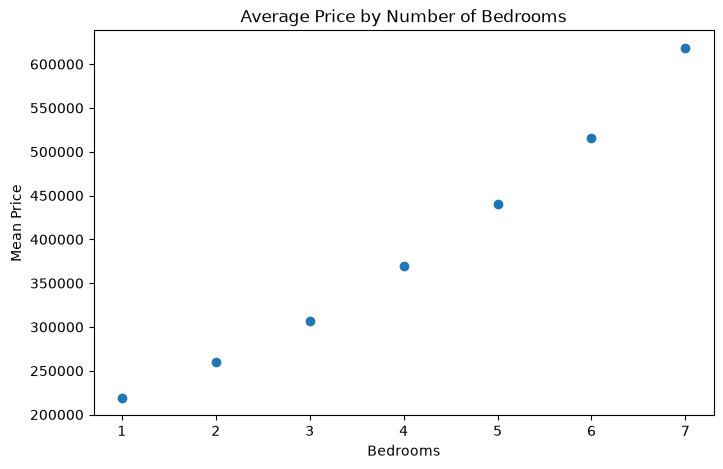

In [70]:
plt.figure(figsize=(8, 5))

plt.scatter(
    bedroom_price.index,
    bedroom_price["mean"]
)

plt.xlabel("Bedrooms")
plt.ylabel("Mean Price")
plt.title(
    "Average Price by Number of Bedrooms"
)

plt.show()

In [71]:
target_corr = (
    df.select_dtypes(include=np.number)
    .corr()["Price"]
    .drop("Price")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(target_corr)

Area_sqft              0.869867
Bedrooms               0.731188
Bathrooms              0.622860
Distance_to_City_km   -0.352630
Age_years             -0.145901
School_Rating          0.042303
Floors                 0.041779
Name: Price, dtype: float64


In [72]:
quality_report = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percent":
        df.isna().mean() * 100,
    "Unique_Count": df.nunique()
})

quality_report["Unique_Percent"] = (
    quality_report["Unique_Count"]
    /
    len(df)
    * 100
)

print(quality_report)

                    Data_Type  Missing_Count  Missing_Percent  Unique_Count  \
Area_sqft             float64              0              0.0          4325   
Bedrooms                int64              0              0.0             7   
Bathrooms             float64             40              0.8             5   
Age_years               int64              0              0.0            61   
Floors                  int64              0              0.0             3   
Location                  str              0              0.0             3   
Distance_to_City_km   float64             50              1.0           441   
HasGarage                 str              0              0.0             2   
School_Rating         float64            100              2.0          1524   
Price                   int64              0              0.0          2566   

                     Unique_Percent  
Area_sqft                     86.50  
Bedrooms                       0.14  
Bathrooms       